In [ ]:
#TASK 1
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 952s 6us/step
Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

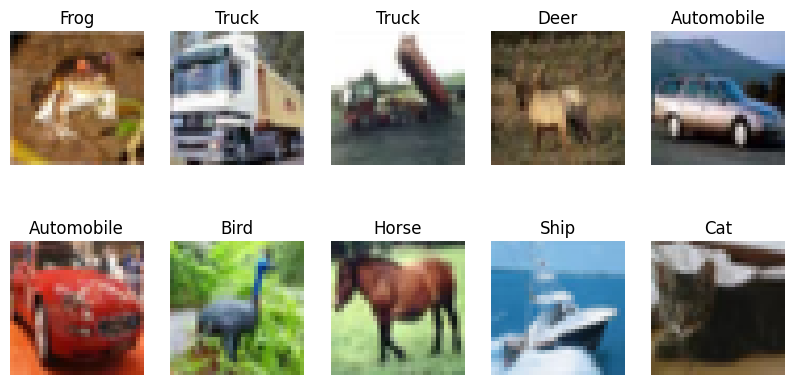

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.show()

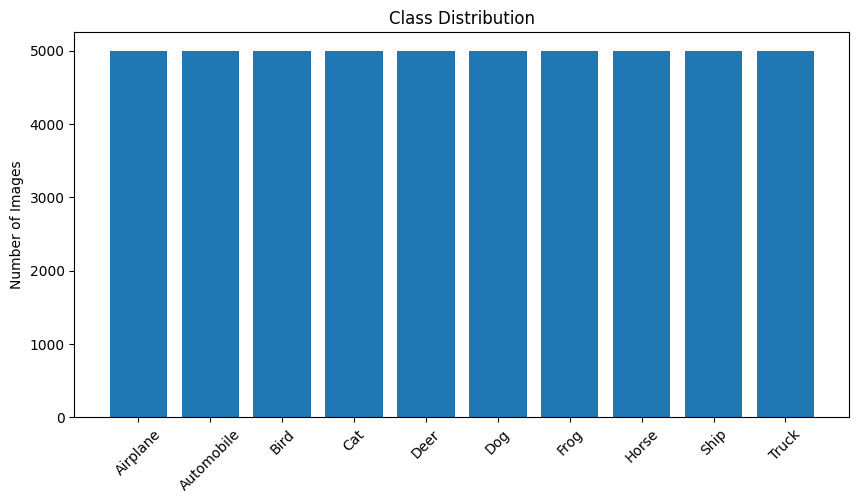

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10,5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
model = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.3639 - loss: 1.7148 - val_accuracy: 0.5026 - val_loss: 1.3621
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5137 - loss: 1.3487 - val_accuracy: 0.5983 - val_loss: 1.1329
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5867 - loss: 1.1655 - val_accuracy: 0.6505 - val_loss: 1.0076
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6295 - loss: 1.0543 - val_accuracy: 0.6806 - val_loss: 0.9054
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6643 - loss: 0.9584 - val_accuracy: 0.6905 - val_loss: 0.8842
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6913 - loss: 0.8831 - val_accuracy: 0.7120 - val_loss: 0.8222
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7106 - loss: 0.8234 - val_accuracy: 0.7056 - val_loss: 0.8442
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7315 - loss: 0.7712 - val_accuracy: 

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test_cat)
print("\nTest Accuracy:", accuracy)
print("Test Loss:", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7308 - loss: 0.8016

Test Accuracy: 0.7307999730110168
Test Loss: 0.801644504070282


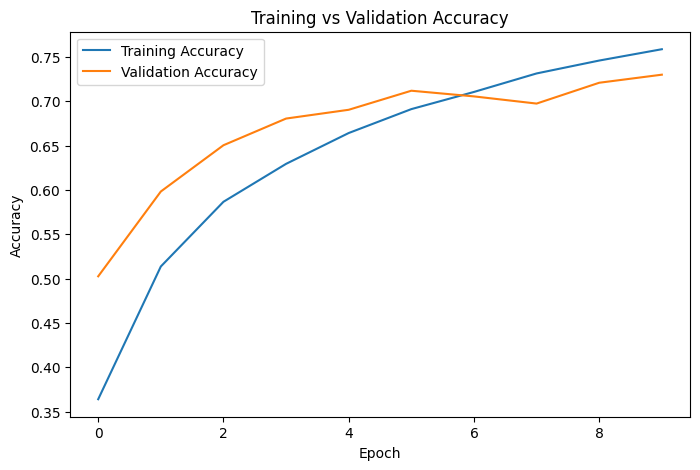

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

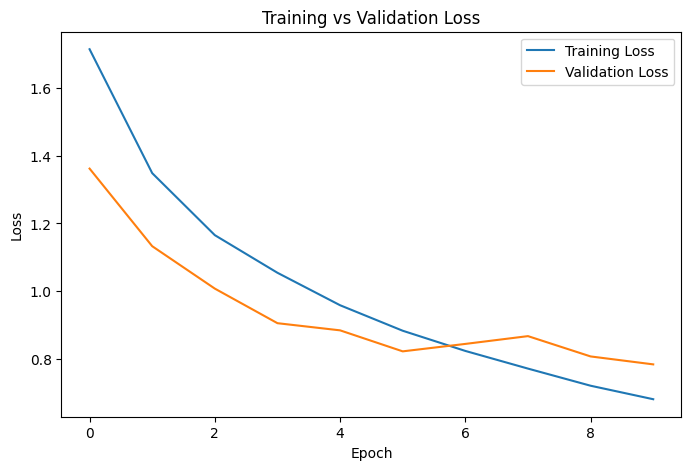

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


In [ ]:
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy  : 0.7308
Precision : 0.7452
Recall    : 0.7308
F1-score  : 0.7332

Classification Report:

              precision    recall  f1-score   support

    Airplane       0.75      0.80      0.77      1000
  Automobile       0.86      0.86      0.86      1000
        Bird       0.69      0.59      0.63      1000
         Cat       0.48      0.64      0.55      1000
        Deer       0.60      0.76      0.67      1000
         Dog       0.69      0.54      0.61      1000
        Frog       0.88      0.69      0.77      1000
       Horse       0.79      0.78      0.78      1000
        Ship       0.88      0.84      0.86      1000
       Truck       0.83      0.82      0.82      1000

    accuracy                           0.73     10000
   macro avg       0.75      0.73      0.73     10000
weighted avg       0.75      0.73      0.73     10000



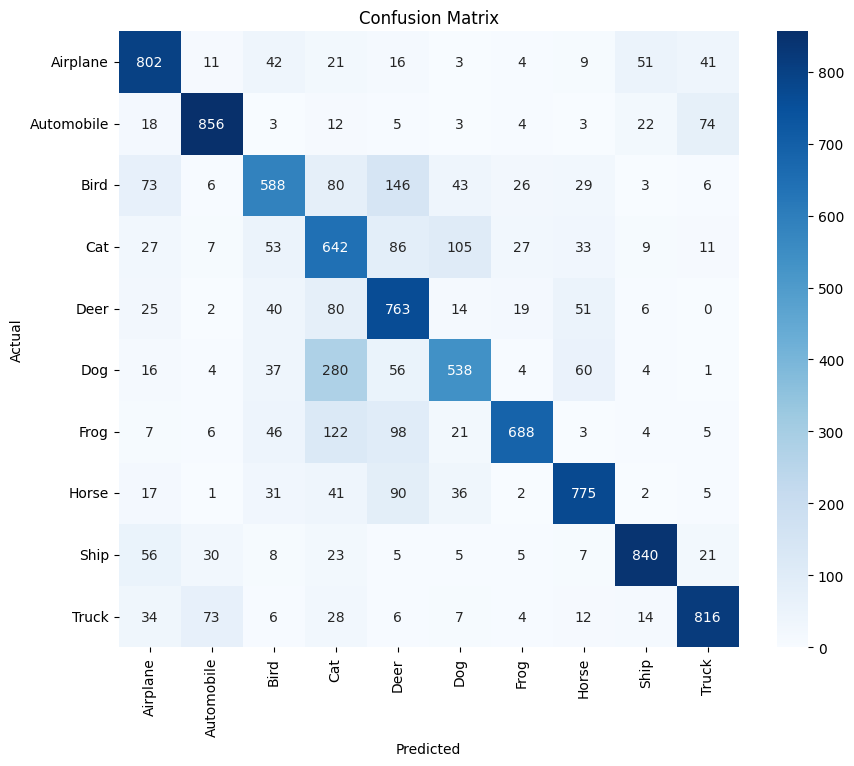

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print("Trainable Parameters\n")
for layer in model.layers:
    print(f"{layer.name}: {layer.count_params()}")

Trainable Parameters

conv2d: 896
max_pooling2d: 0
conv2d_1: 18496
max_pooling2d_1: 0
conv2d_2: 73856
max_pooling2d_2: 0
flatten: 0
dense: 262272
dropout: 0
dense_1: 1290


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step


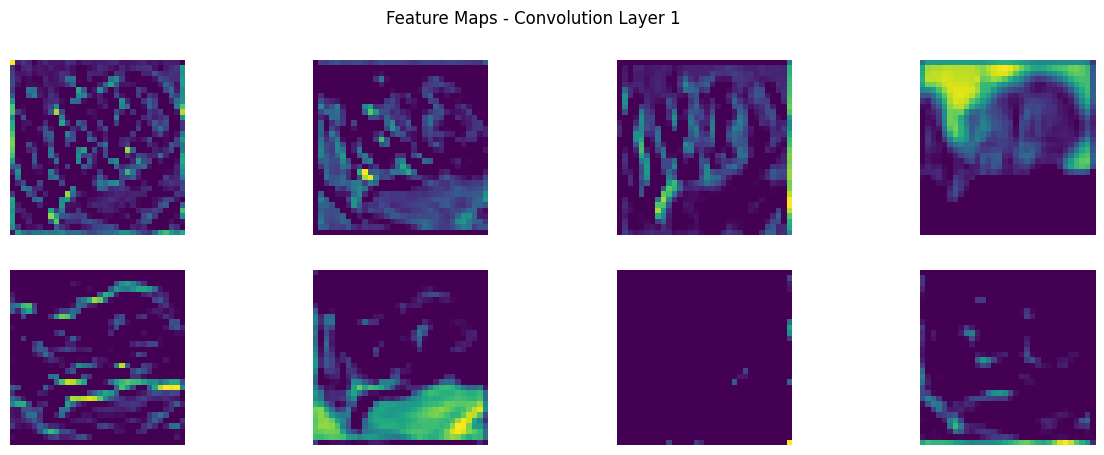

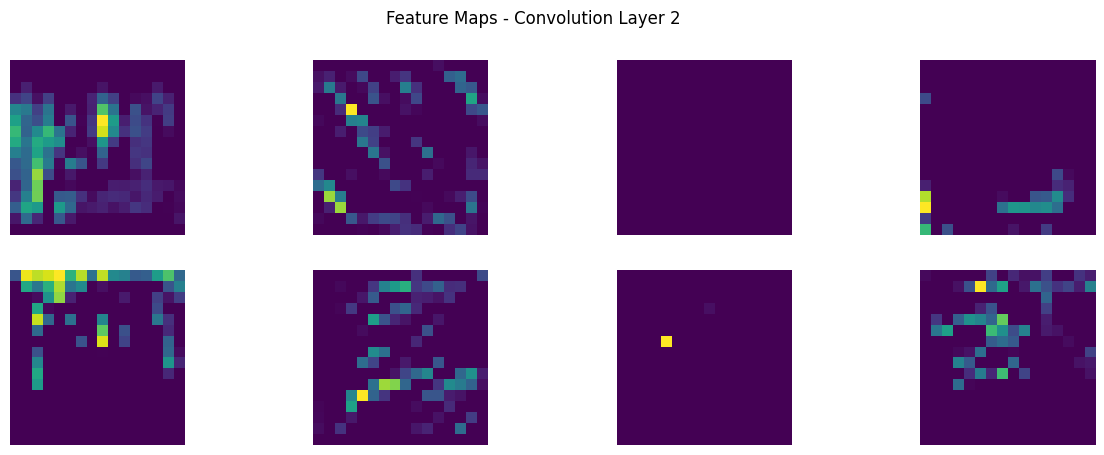

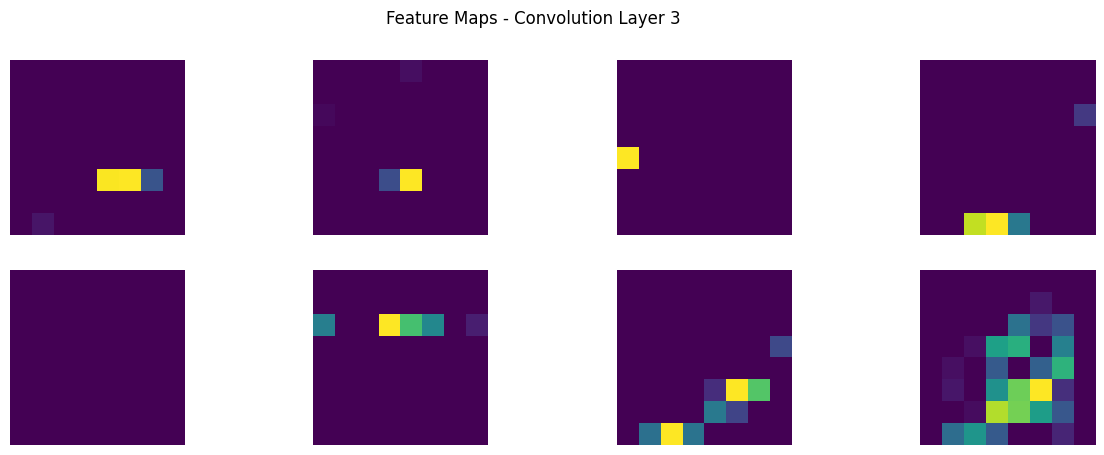

In [ ]:
layer_outputs = [layer.output for layer in model.layers if isinstance(layer, layers.Conv2D)]
feature_model = tf.keras.models.Model(inputs=model.inputs, outputs=layer_outputs)

sample = x_test[0].reshape(1,32,32,3)
feature_maps = feature_model.predict(sample)

for layer_num, fmap in enumerate(feature_maps):
    plt.figure(figsize=(15,5))
    for i in range(min(8, fmap.shape[-1])):
        plt.subplot(2,4,i+1)
        plt.imshow(fmap[0,:,:,i], cmap='viridis')
        plt.axis("off")
    plt.suptitle(f"Feature Maps - Convolution Layer {layer_num+1}")
    plt.show()

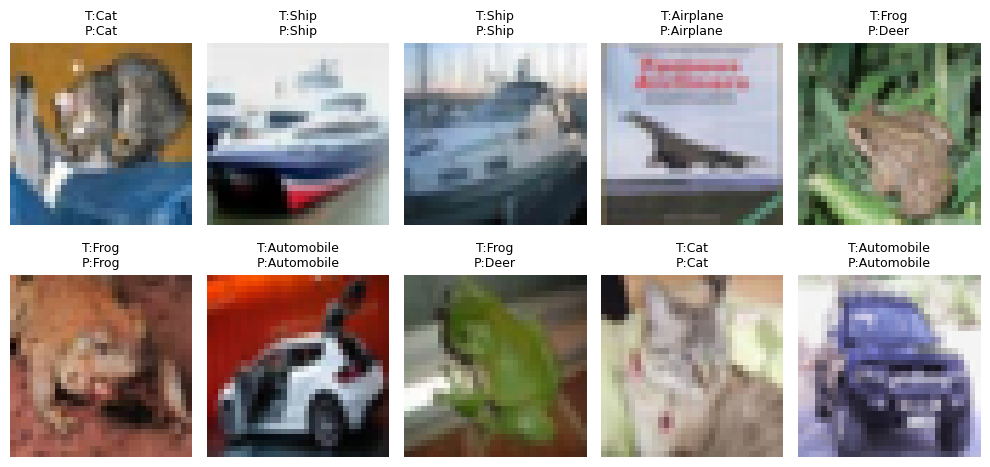

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title(f"T:{class_names[y_true[i]]}\nP:{class_names[y_pred[i]]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4552 - loss: 1.5185 - val_accuracy: 0.5684 - val_loss: 1.2564
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6025 - loss: 1.1363 - val_accuracy: 0.6303 - val_loss: 1.0753
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6539 - loss: 0.9976 - val_accuracy: 0.6549 - val_loss: 1.0052
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6848 - loss: 0.9060 - val_accuracy: 0.6770 - val_loss: 0.9362
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7086 - loss: 0.8407 - val_accuracy: 0.6787 - val_loss: 0.9407
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7293 - loss: 0.7832 - val_accuracy: 0.6939 - val_loss: 0.8952
Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.4134 - loss: 1.6204 - val_accuracy: 0.5140 - val_loss: 1.3637
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5461 - loss: 1.2765 - val_accuracy: 0.5768 - v

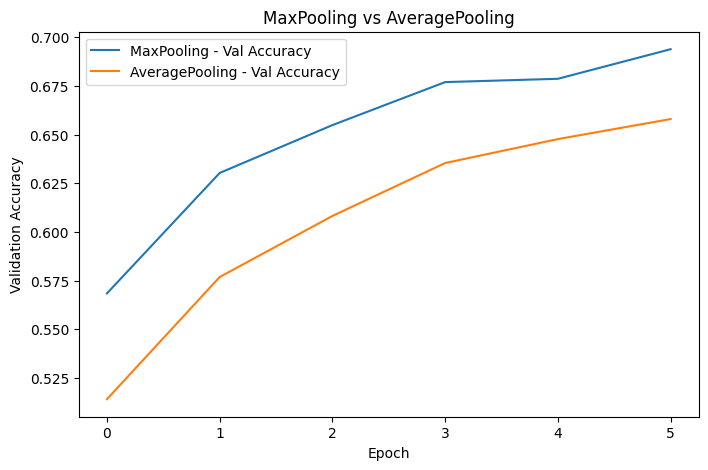

In [ ]:
def build_pooling_model(pooling_type):
    return models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        pooling_type((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        pooling_type((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

model_max = build_pooling_model(layers.MaxPooling2D)
model_max.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_max = model_max.fit(x_train, y_train_cat, epochs=6, batch_size=64, validation_split=0.2, verbose=1)

model_avg = build_pooling_model(layers.AveragePooling2D)
model_avg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_avg = model_avg.fit(x_train, y_train_cat, epochs=6, batch_size=64, validation_split=0.2, verbose=1)

print("\nMaxPooling final val accuracy:", hist_max.history['val_accuracy'][-1])
print("AveragePooling final val accuracy:", hist_avg.history['val_accuracy'][-1])

plt.figure(figsize=(8,5))
plt.plot(hist_max.history['val_accuracy'], label='MaxPooling - Val Accuracy')
plt.plot(hist_avg.history['val_accuracy'], label='AveragePooling - Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("MaxPooling vs AveragePooling")
plt.legend()
plt.show()

In [ ]:
results = []

configs = [
    {"filters": 16, "kernel": (3,3), "stride": 1},
    {"filters": 32, "kernel": (3,3), "stride": 1},
    {"filters": 32, "kernel": (5,5), "stride": 1},
    {"filters": 32, "kernel": (3,3), "stride": 2},
]

for cfg in configs:
    m = models.Sequential([
        layers.Conv2D(cfg["filters"], cfg["kernel"], strides=cfg["stride"], activation='relu', padding='same', input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(cfg["filters"]*2, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(x_train, y_train_cat, epochs=5, batch_size=64, validation_split=0.2, verbose=0)
    val_acc = h.history['val_accuracy'][-1]
    results.append({"config": cfg, "val_accuracy": val_acc})
    print(f"{cfg} -> val_accuracy: {val_acc:.4f}")

print("\nSummary:")
for r in results:
    print(r)

{'filters': 16, 'kernel': (3, 3), 'stride': 1} -> val_accuracy: 0.6356
{'filters': 32, 'kernel': (3, 3), 'stride': 1} -> val_accuracy: 0.6814
{'filters': 32, 'kernel': (5, 5), 'stride': 1} -> val_accuracy: 0.6711
{'filters': 32, 'kernel': (3, 3), 'stride': 2} -> val_accuracy: 0.6510

Summary:
{'config': {'filters': 16, 'kernel': (3, 3), 'stride': 1}, 'val_accuracy': 0.6355999708175659}
{'config': {'filters': 32, 'kernel': (3, 3), 'stride': 1}, 'val_accuracy': 0.6814000010490417}
{'config': {'filters': 32, 'kernel': (5, 5), 'stride': 1}, 'val_accuracy': 0.6711000204086304}
{'config': {'filters': 32, 'kernel': (3, 3), 'stride': 2}, 'val_accuracy': 0.6510000228881836}
